In [66]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.layers as layers
import matplotlib.pyplot as plt
import math
from tensorflow.keras.models import Model
from tensorflow.keras.layers import BatchNormalization, Add, UpSampling3D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv3D, Input, MaxPooling3D, Dropout, concatenate, UpSampling3D, ReLU
from tensorflow.keras import backend as K
import nibabel as nib
import os 


def global_normalized_cross_correlation_loss():
    def ncc(y_true, y_pred):
        """Computes the normalized cross-correlation (NCC) loss.

        Parameters
        ----------
        y_true : tf.Tensor
            The static image to which the moving image is aligned.
        y_pred : tf.Tensor
            The moving image, the same shape as the static image.

        Returns
        -------
        loss : tf.Tensor, shape ()
            Normalized cross-correlation loss between the static and the
            moving images, averaged over the batch. Range is [-1.0, 1.0].
            The best value is -1 (perfect match) and the worst is 1.

        References
        ----------
        .. [1] `Wikipedia entry for the Cross-correlation
               <https://en.wikipedia.org/wiki/Cross-correlation>`_

        """
        ndim = tf.keras.backend.ndim(y_true)-2

        # shape (N, 1, 1, C)
        y_true_mean = tf.reduce_mean(y_true, axis=range(1, ndim+1),
                                     keepdims=True)
        y_pred_mean = tf.reduce_mean(y_pred, axis=range(1, ndim+1),
                                     keepdims=True)
        plt.ylabel('Loss')

        y_true_hat = tf.math.l2_normalize(y_true-y_true_mean,
                                          axis=range(1, ndim+1))

        y_pred_hat = tf.math.l2_normalize(y_pred-y_pred_mean,
                                          axis=range(1, ndim+1))

        return -tf.reduce_mean(tf.reduce_sum(y_true_hat * y_pred_hat,
                                             axis=range(1, ndim+1)))
    return ncc


def local_normalized_cross_correlation_loss(window=(9,9,9), eps=1e-5):
    """
    Code borrowed from https://github.com/voxelmorph/voxelmorph/blob/legacy/src/losses.py#L28
    Paper: https://openaccess.thecvf.com/content_cvpr_2018/papers/Balakrishnan_An_Unsupervised_Learning_CVPR_2018_paper.pdf
    """
    def ncc(I, J, window=window):
        # get dimension of volume
        # assumes I, J are sized [batch_size, *vol_shape, nb_feats]
        # ndims = len(I.get_shape().as_list()) - 2
        ndims = tf.keras.backend.ndim(I)-2
        assert ndims in [1, 2, 3], "volumes should be 1 to 3 dimensions. found: %d" % ndims

        # set window size
        if window is None:
            window = [9] * ndims

        # get convolution function
        conv_fn = getattr(tf.nn, 'conv%dd' % ndims)

        # compute CC squares
        I2 = I*I
        J2 = J*J
        IJ = I*J

        # compute filters
        sum_filt = tf.ones([*window, 1, 1])
        strides = [1] * (ndims + 2)
        padding = 'SAME'

        # compute local sums via convolution
        I_sum = conv_fn(I, sum_filt, strides, padding)
        J_sum = conv_fn(J, sum_filt, strides, padding)
        I2_sum = conv_fn(I2, sum_filt, strides, padding)
        J2_sum = conv_fn(J2, sum_filt, strides, padding)
        IJ_sum = conv_fn(IJ, sum_filt, strides, padding)

        # compute cross correlation
        win_size = np.prod(window)
        u_I = I_sum/win_size
        u_J = J_sum/win_size

        cross = IJ_sum - u_J*I_sum - u_I*J_sum + u_I*u_J*win_size
        I_var = I2_sum - 2 * u_I * I_sum + u_I*u_I*win_size
        J_var = J2_sum - 2 * u_J * J_sum + u_J*u_J*win_size

        cc = cross*cross / (I_var*J_var + eps)

        # return negative cc.
        return -tf.reduce_mean(cc)
    return ncc

# vein. Portal veins are well enhanced and some enhancement of the hepatic veins is also seen on the portal venous phase. T
def gradient_loss(norm=2):
    """
    Code borrowed from https://github.com/voxelmorph/voxelmorph/blob/legacy/pytorch/losses.py#L13
    Paper: https://openaccess.thecvf.com/content_cvpr_2018/papers/Balakrishnan_An_Unsupervised_Learning_CVPR_2018_paper.pdf
    """
    def grad_loss(_, phi):
        di = tf.abs(phi[:, 1:, :, :, :] - phi[:, :-1, :, :, :])
        dj = tf.abs(phi[:, :, 1:, :, :] - phi[:, :, :-1, :, :])
        dk = tf.abs(phi[:, :, :, 1:, :] - phi[:, :, :, :-1, :])

        loss = tf.reduce_mean(di) + tf.reduce_mean(dj) + tf.reduce_mean(dk)
        if norm == 2:
            loss = tf.reduce_mean(di**2) + tf.reduce_mean(dj**2) + tf.reduce_mean(dk**2)    
        return loss
    return grad_loss

def regular_grid_3d(depth, height, width):
    """Returns a 3-D regular grid.

    Parameters
    ----------
    depth : int
        The desired depth of the grid.
    height : int
        The desired height of the grid.
    width : int
        The desired width of the grid.
    Returns
    -------
    grid : tf.Tensor, shape (D, H, W, 3)
        A 3-D regular grid, values normalized to [-1.0, 1.0]
        range.

    Notes
    -----
    Sampling using the regular grid is an identity transformation, i.e.,
    it results in the same input and output images.

    References
    ----------
    .. [1] `NumPy, "numpy.meshgrid"
        <https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html>`_
    .. [2] `NumPy, "numpy.indices"
        <https://numpy.org/doc/stable/reference/generated/numpy.indices.html>`_
    moved = tf.add_n([moving_a,moving_b, moving_c,
                      moving_d,moving_e, moving_f,
                      moving_g, moving_h], name=name)

    """
    i = tf.linspace(-1.0, 1.0, depth)
    j = tf.linspace(-1.0, 1.0, height)
    k = tf.linspace(-1.0, 1.0, width)

    I, J, K = tf.meshgrid(i, j, k, indexing='ij')

    grid = tf.stack([I, J, K], axis=-1)
    return grid


def grid_sample_3d(moving, grid, name=None):
    """Given a moving image and a sampling grid as input, computes the
    transformed image by sampling the moving image at locations given by
    the grid.

    Parameters
    ----------
    moving : tf.Tensor, shape (N, D, H, W, C)
        The moving image.
    grid : tf.Tensor, shape (N, D, H, W, C)
        A tensor of sampling points (x, y, z). The x, y and z values should be
        normalized to [-1.0, 1.0] range.
    name : str
        Name for the operation.

    Returns
    -------
    moved : tf.Tensor, shape (N, D, H, W, C)
        The transformed image.

    Notes
    -----
    Let M be the moving image of shape (H, W, C), T be the transformed
    image of the same shape and G be the 2D sampling grid of shape
    (H, W, 2). The value of T at a location (x, y) is T[y, x, :] =
    M[y', x', :] where [x', y'] = G[y, x, :].

    Further, [x', y'] = [x + dx, y + dy] where [dx, dy] are the
    displacements outputted by the CNN. When dx and dy are 0, the
    sampling grid G is a regular grid and the transformed image is the
    same as the moving image.

    Since the sampling point (x + dx, y + dy) can be non-integral, the
    value M[y', x'] is calculated using bi-linear interpolation.
    
    => 이전 value를 가져오는 걸로 수정

    References
    ----------9
    .. [1] `Jaderberg, Max, Karen Simonyan, and Andrew Zisserman. "Spatial
        transformer networks." Advances in neural information processing
        systems. 2015. <https://arxiv.org/abs/1506.02025>`_
    -------
    .. [2] `TensorFlow implementation of spatial transformer networks.
        <https://github.com/tensorflow/models/tree/master/research/transformer>`_
    .. [3] `Spatial Transformer Networks by Kushagra Bhatnagar
        <https://link.medium.com/0b2OrmqVO5>`_
        
    """
    nb, nd, nh, nw, nc = tf.shape(moving)
    
    i = grid[..., 0]  # shape (N, D, H, W)
    j = grid[..., 1]
    k = grid[..., 2]
    i = tf.cast(i, 'float32')
    j = tf.cast(j, 'float32')
    k = tf.cast(k, 'float32')

    # Scale i, j and k from [-1.0, 1.0] to [0, D], [0, H] and [0, W] respectively.
    i = (i + 1.0) * 0.5 * tf.cast(nd-1, 'float32')
    j = (j + 1.0) * 0.5 * tf.cast(nh-1, 'float32')
    k = (k + 1.0) * 0.5 * tf.cast(nw-1, 'float32')

    i_max = tf.cast(nd - 1, 'int32')
    j_max = tf.cast(nh - 1, 'int32')
    k_max = tf.cast(nw - 1, 'int32')
    zero = tf.constant(0, 'int32')

    # The value at (i, j, k) is a weighted average of the values at the
    # eight nearest integer locations: (i0, j0, k0), (i0, j0, k1), (i0, j1, k0),
    # (i0, j1, k1), (i1, j0, k0), (i1, j0, k1), (i1, j1, k0) and (i1, j1, k1)
    # where i0 = floor(i), i1 = ceil(i).
    i0 = tf.cast(tf.floor(i), 'int32')
    i1 = i0 + 1
    j0 = tf.cast(tf.floor(j), 'int32')
    j1 = j0 + 1
    k0 = tf.cast(tf.floor(k), 'int32')
    k1 = k0 + 1

    # Make sure indices are within the boundaries of the image.
    i0 = tf.clip_by_value(i0, zero, i_max)
    i1 = tf.clip_by_value(i1, zero, i_max)
    j0 = tf.clip_by_value(j0, zero, j_max)
    j1 = tf.clip_by_value(j1, zero, j_max)
    k0 = tf.clip_by_value(k0, zero, k_max)
    k1 = tf.clip_by_value(k1, zero, k_max)

    # Collect indices of the four corners.
    b = tf.ones_like(i0) * tf.reshape(tf.range(nb), [nb, 1, 1, 1])
    idx_a = tf.stack([b, i1, j0, k0], axis=-1)  # all front-top-left corners
    idx_b = tf.stack([b, i1, j1, k0], axis=-1)  # all front-bottom-left corners
    idx_c = tf.stack([b, i1, j0, k1], axis=-1)  # all front-top-right corners
    idx_d = tf.stack([b, i1, j1, k1], axis=-1)  # all front-bottom-right corners
    idx_e = tf.stack([b, i0, j0, k0], axis=-1)  # all back-top-left corners
    idx_f = tf.stack([b, i0, j1, k0], axis=-1)  # all back-bottom-left corners
    idx_g = tf.stack([b, i0, j0, k1], axis=-1)  # all back-top-right corners
    idx_h = tf.stack([b, i0, j1, k1], axis=-1)  # all back-bottom-right corners
    # shape (N, D, H, W, 3)
    # print(idx_a.shape)
    
    # Collect values at the corners.
    moving_a = tf.gather_nd(moving, idx_a)  # all front-top-left values
    moving_b = tf.gather_nd(moving, idx_b)  # all front-bottom-left values
    moving_c = tf.gather_nd(moving, idx_c)  # all front-top-right values
    moving_d = tf.gather_nd(moving, idx_d)  # all front-bottom-right values
    moving_e = tf.gather_nd(moving, idx_e)  # all back-top-left values
    moving_f = tf.gather_nd(moving, idx_f)  # all back-bottom-left values
    moving_g = tf.gather_nd(moving, idx_g)  # all back-top-right values
    moving_h = tf.gather_nd(moving, idx_h)  # all back-bottom-right values

    i0_f = tf.cast(i0, 'int32')
    i1_f = tf.cast(i1, 'int32')
    j0_f = tf.cast(j0, 'int32')
    j1_f = tf.cast(j1, 'int32')
    k0_f = tf.cast(k0, 'int32')
    k1_f = tf.cast(k1, 'int32')
    
    i = tf.cast(i, 'float32')
    j = tf.cast(j, 'float32')
    k = tf.cast(k, 'float32')

    i_r = tf.round(i)
    j_r = tf.round(j)
    k_r = tf.round(k)
    i_r = tf.cast(i_r, 'int32')
    j_r = tf.cast(j_r, 'int32')
    k_r = tf.cast(k_r, 'int32')

    _i0 = tf.equal(i_r, i0_f)
    _j0 = tf.equal(j_r, j0_f)
    _k0 = tf.equal(k_r, k0_f)
    _i1 = tf.equal(i_r, i1_f)
    _j1 = tf.equal(j_r, j1_f)
    _k1 = tf.equal(k_r, k1_f)
    
    _i0 = tf.cast(_i0, 'float32')
    _j0 = tf.cast(_j0, 'float32')
    _k0 = tf.cast(_k0, 'float32')
    _i1 = tf.cast(_i1, 'float32')
    _j1 = tf.cast(_j1, 'float32')
    _k1 = tf.cast(_k1, 'float32')
    
#     _i0 = tf.case([(tf.less(i_r, i1_f), f1)], default=f2)
#     _i1 = tf.case([tf.greater(i_r,i0_f), _one])
#     _j0 = tf.case([tf.less(j_r,j1_f), _one])
#     _j1 = tf.case([tf.greater(j_r,j0_f), _one])
#     _k0 = tf.case([tf.less(k_r,k1_f), _one])
#     _k1 = tf.case([tf.greater(k_r,k0_f), _one])

    
    # Calculate the weights.
#     wa = tf.expand_dims((i_r * (j1_f - j) * (k1_f - k), axis=-1)
#     wb = tf.expand_dims((i - i0_f) * (j - j0_f) * (k1_f - k), axis=-1)
#     wc = tf.expand_dims((i - i0_f) * (j1_f - j) * (k - k0_f), axis=-1)
#     wd = tf.expand_dims((i - i0_f) * (j - j0_f) * (k - k0_f), axis=-1)
#     we = tf.expand_dims((i1_f - i) * (j1_f - j) * (k1_f - k), axis=-1)
#     wf = tf.expand_dims((i1_f - i) * (j - j0_f) * (k1_f - k), axis=-1)
#     wg = tf.expand_dims((i1_f - i) * (j1_f - j) * (k - k0_f), axis=-1)
#     wh = tf.expand_dims((i1_f - i) * (j - j0_f) * (k - k0_f), axis=-1

    wa = tf.expand_dims(_i1 * _j0 * _k0, axis=-1)
    wb = tf.expand_dims(_i1 * _j1 * _k0, axis=-1)
    wc = tf.expand_dims(_i1 * _j0 * _k1, axis=-1)
    wd = tf.expand_dims(_i1 * _j1 * _k1, axis=-1)
    we = tf.expand_dims(_i0 * _j0 * _k0, axis=-1)
    wf = tf.expand_dims(_i0 * _j1 * _k0, axis=-1)
    wg = tf.expand_dims(_i0 * _j0 * _k1, axis=-1)
    wh = tf.expand_dims(_i0 * _j1 * _k1, axis=-1)
    
    total = wa+wb+wc+wd+we+wf+wg+wh
    
    # Calculate the weighted sum.
    moved = tf.add_n([wa * moving_a, wb * moving_b, wc * moving_c,
                      wd * moving_d, we * moving_e, wf * moving_f,
                      wg * moving_g, wh * moving_h], name=name)
    moved = tf.divide(moved, total)
#     moved = moving_a
    
    return moved

In [67]:
def grid_sample_3d2(moving, grid, name=None):
    """Given a moving image and a sampling grid as input, computes the
    transformed image by sampling the moving image at locations given by
    the grid.

    Parameters
    ----------
    moving : tf.Tensor, shape (N, D, H, W, C)
        The moving image.
    grid : tf.Tensor, shape (N, D, H, W, C)
        A tensor of sampling points (x, y, z). The x, y and z values should be
        normalized to [-1.0, 1.0] range.
    name : str
        Name for the operation.

    Returns
    -------
    moved : tf.Tensor, shape (N, D, H, W, C)
        The transformed image.

    Notes
    -----
    Let M be the moving image of shape (H, W, C), T be the transformed
    image of the same shape and G be the 2D sampling grid of shape
    (H, W, 2). The value of T at a location (x, y) is T[y, x, :] =
    M[y', x', :] where [x', y'] = G[y, x, :].

    Further, [x', y'] = [x + dx, y + dy] where [dx, dy] are the
    displacements outputted by the CNN. When dx and dy are 0, the
    sampling grid G is a regular grid and the transformed image is the
    same as the moving image.

    Since the sampling point (x + dx, y + dy) can be non-integral, the
    value M[y', x'] is calculated using bi-linear interpolation.
    
    => 이전 value를 가져오는 걸로 수정

    References
    ----------
    .. [1] `Jaderberg, Max, Karen Simonyan, and Andrew Zisserman. "Spatial
        transformer networks." Advances in neural information processing
        systems. 2015. <https://arxiv.org/abs/1506.02025>`_
    .. [2] `TensorFlow implementation of spatial transformer networks.
        <https://github.com/tensorflow/models/tree/master/research/transformer>`_
    .. [3] `Spatial Transformer Networks by Kushagra Bhatnagar
        <https://link.medium.com/0b2OrmqVO5>`_
        
    """
    nb, nd, nh, nw, nc = tf.shape(moving)
    
    i = grid[..., 0]  # shape (N, D, H, W)
    j = grid[..., 1]
    k = grid[..., 2]
    i = tf.cast(i, 'float32')
    j = tf.cast(j, 'float32')
    k = tf.cast(k, 'float32')

    # Scale i, j and k from [-1.0, 1.0] to [0, D], [0, H] and [0, W] respectively.
    i = (i + 1.0) * 0.5 * tf.cast(nd-1, 'float32')
    j = (j + 1.0) * 0.5 * tf.cast(nh-1, 'float32')
    k = (k + 1.0) * 0.5 * tf.cast(nw-1, 'float32')

    i_max = tf.cast(nd - 1, 'int32')
    j_max = tf.cast(nh - 1, 'int32')
    k_max = tf.cast(nw - 1, 'int32')
    zero = tf.constant(0, 'int32')

    # The value at (i, j, k) is a weighted average of the values at the
    # eight nearest integer locations: (i0, j0, k0), (i0, j0, k1), (i0, j1, k0),
    # (i0, j1, k1), (i1, j0, k0), (i1, j0, k1), (i1, j1, k0) and (i1, j1, k1)
    # where i0 = floor(i), i1 = ceil(i).
    i0 = tf.cast(tf.floor(i), 'int32')
    i1 = i0 + 1
    j0 = tf.cast(tf.floor(j), 'int32')
    j1 = j0 + 1
    k0 = tf.cast(tf.floor(k), 'int32')
    k1 = k0 + 1

    # Make sure indices are within the boundaries of the image.
    i0 = tf.clip_by_value(i0, zero, i_max)
    i1 = tf.clip_by_value(i1, zero, i_max)
    j0 = tf.clip_by_value(j0, zero, j_max)
    j1 = tf.clip_by_value(j1, zero, j_max)
    k0 = tf.clip_by_value(k0, zero, k_max)
    k1 = tf.clip_by_value(k1, zero, k_max)

    # Collect indices of the four corners.
    b = tf.ones_like(i0) * tf.reshape(tf.range(nb), [nb, 1, 1, 1])
    idx_a = tf.stack([b, i1, j0, k0], axis=-1)  # all front-top-left corners
    idx_b = tf.stack([b, i1, j1, k0], axis=-1)  # all front-bottom-left corners
    idx_c = tf.stack([b, i1, j0, k1], axis=-1)  # all front-top-right corners
    idx_d = tf.stack([b, i1, j1, k1], axis=-1)  # all front-bottom-right corners
    idx_e = tf.stack([b, i0, j0, k0], axis=-1)  # all back-top-left corners
    idx_f = tf.stack([b, i0, j1, k0], axis=-1)  # all back-bottom-left corners
    idx_g = tf.stack([b, i0, j0, k1], axis=-1)  # all back-top-right corners
    idx_h = tf.stack([b, i0, j1, k1], axis=-1)  # all back-bottom-right corners
    # shape (N, D, H, W, 3)

    # Collect values at the corners.
    moving_a = tf.gather_nd(moving, idx_a)  # all front-top-left values
    moving_b = tf.gather_nd(moving, idx_b)  # all front-bottom-left values
    moving_c = tf.gather_nd(moving, idx_c)  # all front-top-right values
    moving_d = tf.gather_nd(moving, idx_d)  # all front-bottom-right values
    moving_e = tf.gather_nd(moving, idx_e)  # all back-top-left values
    moving_f = tf.gather_nd(moving, idx_f)  # all back-bottom-left values
    moving_g = tf.gather_nd(moving, idx_g)  # all back-top-right values
    moving_h = tf.gather_nd(moving, idx_h)  # all back-bottom-right values
    # shape (N, D, H, W, C)

    i0_f = tf.cast(i0, 'float32')
    i1_f = tf.cast(i1, 'float32')
    j0_f = tf.cast(j0, 'float32')
    j1_f = tf.cast(j1, 'float32')
    k0_f = tf.cast(k0, 'float32')
    k1_f = tf.cast(k1, 'float32')

    # Calculate the weights.
    wa = tf.expand_dims((i - i0_f) * (j1_f - j) * (k1_f - k), axis=-1)
    wb = tf.expand_dims((i - i0_f) * (j - j0_f) * (k1_f - k), axis=-1)
    wc = tf.expand_dims((i - i0_f) * (j1_f - j) * (k - k0_f), axis=-1)
    wd = tf.expand_dims((i - i0_f) * (j - j0_f) * (k - k0_f), axis=-1)
    we = tf.expand_dims((i1_f - i) * (j1_f - j) * (k1_f - k), axis=-1)
    wf = tf.expand_dims((i1_f - i) * (j - j0_f) * (k1_f - k), axis=-1)
    wg = tf.expand_dims((i1_f - i) * (j1_f - j) * (k - k0_f), axis=-1)
    wh = tf.expand_dims((i1_f - i) * (j - j0_f) * (k - k0_f), axis=-1)

    # Calculate the weighted sum.
    moved = tf.add_n([wa * moving_a, wb * moving_b, wc * moving_c,
                      wd * moving_d, we * moving_e, wf * moving_f,
                      wg * moving_g, wh * moving_h], name=name)
    return moved

In [68]:
class AffineNet(object):
    def __init__(self, input_shape=(128, 128, 64), optimizer='adam', loss=None,
                 metrics=None, loss_weights=None):
        in_channels = 1
        out_channels = 3
        d, h, w = input_shape
        input_shape = input_shape + (in_channels,)
        moving = layers.Input(shape=input_shape, name='moving')
        static = layers.Input(shape=input_shape, name='static')
        moving_gt = layers.Input(shape=input_shape, name='moving_gt')
        
        x_in = layers.concatenate([static, moving], axis=-1)

        x1 = layers.Conv3D(16, kernel_size=3, strides=2, padding='same',
                        kernel_initializer='he_normal')(x_in)
        x1 = layers.LeakyReLU(alpha=0.2)(x1)  # 16
     

        x2 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                            kernel_initializer='he_normal')(x1)
        x2 = layers.LeakyReLU(alpha=0.2)(x2)  # 8


        x3 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                            kernel_initializer='he_normal')(x2)
        x3 = layers.LeakyReLU(alpha=0.2)(x3)  # 4
  

        x4 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                            kernel_initializer='he_normal')(x3)
        x4 = layers.LeakyReLU(alpha=0.2)(x4)  # 2 # 4 for 64

        
        x = layers.Flatten()(x4)
        x = layers.Dense(64, activation='relu')(x)  # 4*4*32

        theta_x, theta_y, theta_z = 0, 0, 0
        trans_x, trans_y, trans_z = 0, 0, 0 
        Rx, Ry, Rz = tf.ones([3,3]), tf.ones([3,3]), tf.ones([3,3])
        

#         x = layers.Dense(6, kernel_initializer='zeros',
#                          bias_initializer=tf.constant_initializer([len(theta_x), len(theta_y), len(theta_z), trans_x, trans_y, trans_z]), name='theta')(x)
        x_theta = layers.Dense(6, kernel_initializer='zeros',
                         bias_initializer=tf.constant_initializer([theta_x, theta_y, theta_z, trans_x, trans_y, trans_z]), name='x_theta')(x)
        
        x_reshape = tf.reshape(x_theta, [6])
        theta_x, theta_y, theta_z, trans_x, trans_y, trans_z = x_reshape[0], x_reshape[1], x_reshape[2], x_reshape[3], x_reshape[4], x_reshape[5]
        
        R_x_sin, R_x_cos = tf.math.sin(theta_x),tf.math.cos(theta_x)
        R_y_sin, R_y_cos = tf.math.sin(theta_y), tf.math.cos(theta_z)
        R_z_sin, R_z_cos = tf.math.sin(theta_z), tf.math.cos(theta_y)
        
        Rx = [[1,0,0],[0,R_x_cos, -R_x_sin],[0, R_x_sin,R_x_cos]]
        Ry = [[R_y_cos,0, R_y_sin],[0,1,0], [-R_y_sin, 0, R_y_cos]]
        Rz = [[R_z_cos, -R_z_sin, 0], [R_z_sin, R_z_cos,0],[0,0,1]]
        
        R_matrix_1 = tf.matmul(Rx,Ry)
        R_matrix = tf.matmul(R_matrix_1, Rz)
        # 3 x 3 
        # R_matrix = tf.reshape(R_matrix, [1, 9])
        real_mat = [[R_matrix[0][0], R_matrix[0][1], R_matrix[0][2], trans_x],
                    [R_matrix[1][0], R_matrix[1][1], R_matrix[1][2], trans_y],
                    [R_matrix[2][0], R_matrix[2][1], R_matrix[2][2], trans_z]]
        
#         real_mat = tf.reshape(real_mat, [1, 9])
        
        nb, _ = tf.shape(x)
        self.theta = tf.reshape(real_mat, [nb, 3, 4])
        grid = regular_grid_3d(d, h, w)
        grid_new = grid_transform_3d(self.theta, grid)
        grid_new = tf.clip_by_value(grid_new, -1, 1)
        
        moved = grid_sample_3d2(moving, grid_new, name='moved')
        moved_gt = grid_sample_3d2(moving_gt, grid_new, name='moved_gt')
        
#         inverse_mat = tf.linalg.lu_matrix_inverse(*tf.linalg.lu(real_mat))
#         tf.assert_near(tf.matrix_inverse(real_mat), inverse_mat)
#         inverse_mat = tf.linalg.inv(real_mat2)
    
        model = tf.keras.Model(inputs={'moving': moving, 'static': static, 'moving_gt': moving_gt},
                                outputs={'moved': moved, 'moved_gt': moved_gt, 'x_theta': x_theta}, name='AffineNet')
        
        model.compile(optimizer=optimizer, loss=loss, metrics=metrics,
                      loss_weights=loss_weights)
        
        self.model = model
        
        
        
#     def theta_get(self):
#         return model.get_layer('theta')

    def compile(self, optimizer='adam', loss=None, metrics=None,
                loss_weights=None):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics,
                           loss_weights=loss_weights)

    def summary(self):
        return self.model.summary()

    def fit(self, x=None, y=None, batch_size=None, epochs=1, verbose=1,
            callbacks=None, validation_split=0.0, validation_data=None,
            shuffle=True, initial_epoch=0, steps_per_epoch=None,
            validation_steps=None, validation_batch_size=None,
            validation_freq=1, max_queue_size=10, workers=1,
            use_multiprocessing=False):
        return self.model.fit(x=x, y=y, batch_size=batch_size,
                              epochs=epochs, verbose=verbose,
                              callbacks=callbacks,
                              validation_split=validation_split,
                              validation_data=validation_data, shuffle=shuffle,
                              initial_epoch=initial_epoch,
                              steps_per_epoch=steps_per_epoch,
                              validation_steps=validation_steps,
                              validation_batch_size=validation_batch_size,
                              validation_freq=validation_freq,
                              max_queue_size=max_queue_size, workers=workers,
                              use_multiprocessing=use_multiprocessing)

    def evaluate(self, x=None, y=None, batch_size=None, verbose=1,
                 steps=None, callbacks=None, max_queue_size=10, workers=1,
                 use_multiprocessing=False, return_dict=False):
        return self.model.evaluate(x=x, y=y, batch_size=batch_size,
                                   verbose=verbose, steps=steps,
                                   callbacks=callbacks,
                                   max_queue_size=max_queue_size,
                                   workers=workers,
                                   use_multiprocessing=use_multiprocessing,
                                   return_dict=return_dict)
    
    def predict(self, x, batch_size=None, verbose=0,
                steps=None, callbacks=None, max_queue_size=10, workers=1,
                use_multiprocessing=False):
        return self.model.predict(x=x, batch_size=batch_size,
                                  verbose=verbose, steps=steps,
                                  callbacks=callbacks,
                                  max_queue_size=max_queue_size,
                                  workers=workers,
                                  use_multiprocessing=use_multiprocessing)
    def save_weights(self, filepath, overwrite=True):
        self.model.save_weights(filepath=filepath, overwrite=overwrite, save_format='tf')

    def load_weights(self, filepath):
        self.model.load_weights(filepath)
        
    def save_model(self, filepath):
        self.model.save(filepath)
    
class RegistrationDataLoader(tf.keras.utils.Sequence):
    def __init__(self, moving, static, moving_gt, batch_size=8, shuffle=False):
        """Data loader object that fetches and preprocess batches of images 
        for real-time data feeding to the model.

        Currently supports only numpy arrays as input.
    
        Parameters
        ----------
        moving : ndarray, shape (N, ..., C)
            An array of all the moving images. N is the number of images.
        static : ndarray, shape (1, ..., C)
            The static image.
                         bias_initializer=tf.constant_initializer([theta_x, theta_y, theta_z, trans_x, trans_y, trans_z]), name='theta')(x)
        

        """
        self.moving = moving
        self.static = static
        self.moving_gt = moving_gt
        
        self.batch_size = batch_size
        self.shuffle = shuffle

        if self.shuffle:
            np.random.shuffle(self.moving)

    def __len__(self):
        return math.ceil(len(self.moving) / self.batch_size)

    def __getitem__(self, idx):
        moving = self.moving[idx * self.batch_size: (idx+1) * self.batch_size]
        moving_gt = self.moving_gt[idx * self.batch_size: (idx+1) * self.batch_size]
        static = np.repeat(self.static, repeats=moving.shape[0], axis=0)
        
        return {'moving': moving, 'static': static, 'moving_gt': moving_gt}, static  # input and output

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.moving)

In [69]:
filename4 = "./BTCV_Data/14onehot_gt.nii.gz"
static_gt = nib.load(filename4).get_fdata()
static_gt = static_gt.astype(np.float32)

def gt_dice_loss_():
    
    def dice_loss(y_pred,y_true, smooth=0):
        global static_gt
        y_true_f = K.flatten(K.one_hot(K.cast(y_true, 'int32'), num_classes=14)[..., 1:])
        y_pred_f = K.flatten(static_gt[...,1:])
        intersect = K.sum(y_true_f * y_pred_f, axis=-1)
        denom = K.sum(y_true_f + y_pred_f, axis=-1)

        return 1 - K.mean((2. * intersect / (denom + smooth)))
    
    return dice_loss

In [70]:
def mse_loss_():
    
    def mse_loss(y_true,y_pred, sigma=1.0):
        return 1.0 / (sigma**2) * K.mean(K.square(y_true - y_pred))
    
    return mse_loss

In [71]:
def Ortho_loss_():
    
    def elem_sym_polys_of_eigen_values(M):
        
        sigma1 = tf.add_n([M[0][0], M[1][1], M[2][2]])
        
        sigma2 = tf.add_n([
            M[0][0] * M[1][1],
            M[1][1] * M[2][2],
            M[2][2] * M[0][0]
        ]) - tf.add_n([
            M[0][1] * M[1][0],
            M[1][2] * M[2][1],
            M[2][0] * M[0][2]
        ])
        
        sigma3 = tf.add_n([
            M[0][0] * M[1][1] * M[2][2],
            M[0][1] * M[1][2] * M[2][0],
            M[0][2] * M[1][0] * M[2][1]
        ]) - tf.add_n([
            M[0][0] * M[1][2] * M[2][1],
            M[0][1] * M[1][0] * M[2][2],
            M[0][2] * M[1][1] * M[2][0]
        ])
        
        return sigma1, sigma2, sigma3
    
    def ortho_(y_pred, y_true, eps = 1e-5):
        # 3x4 -> 3x3으로 재정의 
#         print(y_true)
        x_reshape = tf.reshape(y_true, [6])
        theta_x, theta_y, theta_z = x_reshape[0], x_reshape[1], x_reshape[2]
        
        R_x_sin, R_x_cos = tf.math.sin(theta_x),tf.math.cos(theta_x)
        R_y_sin, R_y_cos = tf.math.sin(theta_y), tf.math.cos(theta_z)
        R_z_sin, R_z_cos = tf.math.sin(theta_z), tf.math.cos(theta_y)
        
        Rx = [[1,0,0],[0,R_x_cos, -R_x_sin],[0, R_x_sin,R_x_cos]]
        Ry = [[R_y_cos,0, R_y_sin],[0,1,0], [-R_y_sin, 0, R_y_cos]]
        Rz = [[R_z_cos, -R_z_sin, 0], [R_z_sin, R_z_cos,0],[0,0,1]]
        
        R_matrix_1 = tf.matmul(Rx,Ry)
        R_matrix = tf.matmul(R_matrix_1, Rz)
        # 3 x 3 
        # R_matrix = tf.reshape(R_matrix, [1, 9])
        C_ = [[R_matrix[0][0], R_matrix[0][1], R_matrix[0][2]],
             [R_matrix[1][0], R_matrix[1][1], R_matrix[1][2]],
             [R_matrix[2][0], R_matrix[2][1], R_matrix[2][2]]]

#         [[y_true[0],y_true[1],y_true[2]],
#              [y_true[4],y_true[5],y_true[6]],
#              [y_true[8],y_true[9],y_true[10]]]
        cb = tf.matmul(C_, C_, True) 

        s1, s2, s3 = elem_sym_polys_of_eigen_values(cb)
        ortho_loss = s1 + (1 + eps) * (1 + eps) * s2 / s3 - 3 * 2 * (1 + eps)
        return tf.reduce_sum(ortho_loss) 

    return ortho_

In [72]:
def grid_transform_3d(theta, grid):
    nb = tf.shape(theta)[0]
    nd, nh, nw, _ = tf.shape(grid)

    i = grid[..., 0] # d, h, w
    j = grid[..., 1]
    k = grid[..., 2]

    i_flat = tf.reshape(i, shape=[-1])
    j_flat = tf.reshape(j, shape=[-1])
    k_flat = tf.reshape(k, shape=[-1])

    ones = tf.ones_like(i_flat)

    grid_flat = tf.stack([i_flat, j_flat, k_flat, ones])
    grid_flat = tf.expand_dims(grid_flat, axis=0)
    grid_flat = tf.tile(grid_flat, tf.stack([nb, 1, 1]))  # n, 4, d*h*w

    # 2d 2x3; 3d 3x4
    theta = tf.cast(theta, 'float32')
    grid_flat = tf.cast(grid_flat, 'float32')
    grid_new = tf.matmul(theta, grid_flat)  # n, 3, d*h*w
    
    grid_new = tf.transpose(grid_new, perm=[0,2,1])
    grid_new = tf.reshape(grid_new, [nb, nd, nh, nw, 3])

    return grid_new

In [73]:
batch_size = 1
epochs = 100
lr = 0.0001  # learning rate
input_shape = (64, 128, 128)

In [74]:
# filename = "./mix_data/mixed_affine.nii.gz"
# filename2 = "./static_data_exis/7.nii.gz"
filename = "./BTCV_Data/resize_exis_stack.nii.gz"
filename2 = "./BTCV_Data/static_exis/40.nii.gz"
# filename3 = "./chaos_train_voxel/gt_resize/24.nii.gz"

data = nib.load(filename).get_fdata()
static = nib.load(filename2).get_fdata()

min_value = np.min(data)
max_value = np.max(data)

# data = (data-min_value) / (max_value-min_value)
print(min_value)
print(max_value)

filename3 = "./BTCV_Data/resize_exis_stack_gt.nii.gz"
# filename4 = "./BTCV_Data/static_exis/40.nii.gz"
# filename3 = "./chaos_train_voxel/gt_resize/24.nii.gz"

data_gt = nib.load(filename3).get_fdata()
# static_gt = nib.load(filename4).get_fdata()

x_train = data[:26, ...][..., None]
x_train = x_train.astype(np.float32) 
x_test = data[26:, ...][..., None]
x_test = x_test.astype(np.float32)
x_sample = data[0:30, ...].copy()  # some images to visualize results

static = (static-min_value) / (max_value-min_value)
static = static[None, ..., None]
static = static.astype(np.float32)

gt_train = data_gt[:26, ...][..., None]
gt_train = gt_train.astype(np.float32) 
gt_test = data_gt[26:, ...][..., None]
gt_test = gt_test.astype(np.float32)
gt_sample = data_gt[0:30, ...].copy()

print('Train: ', x_train.shape) 
print('Test: ', x_test.shape)
print('Sample: ', x_sample.shape)
print('Static: ', static.shape)
print('GT_Train: ', gt_train.shape) 
print('GT_Test: ', gt_test.shape)


train_loader = RegistrationDataLoader(x_train, static, gt_train, batch_size=batch_size,
                                      shuffle=False)
test_loader = RegistrationDataLoader(x_test, static, gt_test, batch_size=batch_size,
                                     shuffle=False)
sample_loader = RegistrationDataLoader(x_sample, static, gt_sample, batch_size=batch_size, shuffle=False)

0.0
1.0
Train:  (26, 64, 128, 128, 1)
Test:  (3, 64, 128, 128, 1)
Sample:  (29, 64, 128, 128)
Static:  (1, 64, 128, 128, 1)
GT_Train:  (26, 64, 128, 128, 1)
GT_Test:  (3, 64, 128, 128, 1)


In [75]:
ncc_loss = local_normalized_cross_correlation_loss()
gt_dice_loss = gt_dice_loss_()
mse_loss = mse_loss_()
Ortho_loss = Ortho_loss_()

# Map model outputs to the loss functions and loss weights
loss_weights = {'moved': 0.5, 'moved_gt': 0.5, 'x_theta':0.0}
losses = {'moved': ncc_loss, 'moved_gt': gt_dice_loss, 'x_theta':Ortho_loss}

optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

model = AffineNet(input_shape=input_shape, optimizer=optimizer,
                    loss=losses, loss_weights=loss_weights)

In [76]:
# model.summary()

In [77]:
import tensorflow

early_stop = tensorflow.keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=250, restore_best_weights=True) 
checkpoint_path = "./Affinecheck/1024_1cp.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                   save_weights_only=True,
                                   verbose=1)# Train the model with the new callback

In [78]:
hist = model.fit(train_loader, epochs=epochs, validation_data=test_loader, callbacks=[cp_callback, early_stop])

Epoch 1/100
26/26 [==============================] - ETA: 0s - loss: 0.4282 - tf_op_layer_moved_6_loss: -0.1349 - tf_op_layer_moved_gt_6_loss: 0.9913 - x_theta_loss: 1.6964e-07
Epoch 00001: saving model to ./Affinecheck/1024_1cp.ckpt
26/26 [==============================] - 6s 213ms/step - loss: 0.4282 - tf_op_layer_moved_6_loss: -0.1349 - tf_op_layer_moved_gt_6_loss: 0.9913 - x_theta_loss: 1.6964e-07 - val_loss: 0.4409 - val_tf_op_layer_moved_6_loss: -0.1156 - val_tf_op_layer_moved_gt_6_loss: 0.9973 - val_x_theta_loss: 3.9736e-08
Epoch 2/100
26/26 [==============================] - ETA: 0s - loss: 0.4250 - tf_op_layer_moved_6_loss: -0.1421 - tf_op_layer_moved_gt_6_loss: 0.9921 - x_theta_loss: 3.2095e-08
Epoch 00002: saving model to ./Affinecheck/1024_1cp.ckpt
26/26 [==============================] - 3s 124ms/step - loss: 0.4250 - tf_op_layer_moved_6_loss: -0.1421 - tf_op_layer_moved_gt_6_loss: 0.9921 - x_theta_loss: 3.2095e-08 - val_loss: 0.4395 - val_tf_op_layer_moved_6_loss: -0.1181

26/26 [==============================] - ETA: 0s - loss: 0.4209 - tf_op_layer_moved_6_loss: -0.1504 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 4.5850e-08
Epoch 00016: saving model to ./Affinecheck/1024_1cp.ckpt
26/26 [==============================] - 3s 128ms/step - loss: 0.4209 - tf_op_layer_moved_6_loss: -0.1504 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 4.5850e-08 - val_loss: 0.4368 - val_tf_op_layer_moved_6_loss: -0.1234 - val_tf_op_layer_moved_gt_6_loss: 0.9970 - val_x_theta_loss: 3.9736e-08
Epoch 17/100
26/26 [==============================] - ETA: 0s - loss: 0.4209 - tf_op_layer_moved_6_loss: -0.1504 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 4.5850e-08
Epoch 00017: saving model to ./Affinecheck/1024_1cp.ckpt
26/26 [==============================] - 3s 120ms/step - loss: 0.4209 - tf_op_layer_moved_6_loss: -0.1504 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 4.5850e-08 - val_loss: 0.4368 - val_tf_op_layer_moved_6_loss: -0.1233 - val_tf_o

26/26 [==============================] - ETA: 0s - loss: 0.4207 - tf_op_layer_moved_6_loss: -0.1508 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 4.8142e-08
Epoch 00031: saving model to ./Affinecheck/1024_1cp.ckpt
26/26 [==============================] - 3s 121ms/step - loss: 0.4207 - tf_op_layer_moved_6_loss: -0.1508 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 4.8142e-08 - val_loss: 0.4369 - val_tf_op_layer_moved_6_loss: -0.1232 - val_tf_op_layer_moved_gt_6_loss: 0.9971 - val_x_theta_loss: 0.0000e+00
Epoch 32/100
26/26 [==============================] - ETA: 0s - loss: 0.4207 - tf_op_layer_moved_6_loss: -0.1508 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 2.9802e-08
Epoch 00032: saving model to ./Affinecheck/1024_1cp.ckpt
26/26 [==============================] - 3s 122ms/step - loss: 0.4207 - tf_op_layer_moved_6_loss: -0.1508 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 2.9802e-08 - val_loss: 0.4369 - val_tf_op_layer_moved_6_loss: -0.1232 - val_tf_o

26/26 [==============================] - ETA: 0s - loss: 0.4207 - tf_op_layer_moved_6_loss: -0.1508 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 6.1897e-08
Epoch 00046: saving model to ./Affinecheck/1024_1cp.ckpt
26/26 [==============================] - 3s 119ms/step - loss: 0.4207 - tf_op_layer_moved_6_loss: -0.1508 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 6.1897e-08 - val_loss: 0.4370 - val_tf_op_layer_moved_6_loss: -0.1231 - val_tf_op_layer_moved_gt_6_loss: 0.9970 - val_x_theta_loss: 0.0000e+00
Epoch 47/100
26/26 [==============================] - ETA: 0s - loss: 0.4207 - tf_op_layer_moved_6_loss: -0.1508 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 9.1699e-08
Epoch 00047: saving model to ./Affinecheck/1024_1cp.ckpt
26/26 [==============================] - 3s 119ms/step - loss: 0.4207 - tf_op_layer_moved_6_loss: -0.1508 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 9.1699e-08 - val_loss: 0.4369 - val_tf_op_layer_moved_6_loss: -0.1232 - val_tf_o

26/26 [==============================] - ETA: 0s - loss: 0.4206 - tf_op_layer_moved_6_loss: -0.1510 - tf_op_layer_moved_gt_6_loss: 0.9923 - x_theta_loss: 6.4190e-08
Epoch 00061: saving model to ./Affinecheck/1024_1cp.ckpt
26/26 [==============================] - 3s 120ms/step - loss: 0.4206 - tf_op_layer_moved_6_loss: -0.1510 - tf_op_layer_moved_gt_6_loss: 0.9923 - x_theta_loss: 6.4190e-08 - val_loss: 0.4370 - val_tf_op_layer_moved_6_loss: -0.1231 - val_tf_op_layer_moved_gt_6_loss: 0.9971 - val_x_theta_loss: 9.9341e-08
Epoch 62/100
26/26 [==============================] - ETA: 0s - loss: 0.4204 - tf_op_layer_moved_6_loss: -0.1515 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 6.4190e-08
Epoch 00062: saving model to ./Affinecheck/1024_1cp.ckpt
26/26 [==============================] - 3s 125ms/step - loss: 0.4204 - tf_op_layer_moved_6_loss: -0.1515 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 6.4190e-08 - val_loss: 0.4370 - val_tf_op_layer_moved_6_loss: -0.1230 - val_tf_o

26/26 [==============================] - ETA: 0s - loss: 0.4202 - tf_op_layer_moved_6_loss: -0.1518 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 2.2925e-09 
Epoch 00076: saving model to ./Affinecheck/1024_1cp.ckpt
26/26 [==============================] - 3s 119ms/step - loss: 0.4202 - tf_op_layer_moved_6_loss: -0.1518 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 2.2925e-09 - val_loss: 0.4370 - val_tf_op_layer_moved_6_loss: -0.1231 - val_tf_op_layer_moved_gt_6_loss: 0.9971 - val_x_theta_loss: -1.9868e-08
Epoch 77/100
26/26 [==============================] - ETA: 0s - loss: 0.4202 - tf_op_layer_moved_6_loss: -0.1518 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 9.1699e-08
Epoch 00077: saving model to ./Affinecheck/1024_1cp.ckpt
26/26 [==============================] - 3s 120ms/step - loss: 0.4202 - tf_op_layer_moved_6_loss: -0.1518 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 9.1699e-08 - val_loss: 0.4369 - val_tf_op_layer_moved_6_loss: -0.1232 - val_tf

26/26 [==============================] - ETA: 0s - loss: 0.4203 - tf_op_layer_moved_6_loss: -0.1517 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 8.4822e-08
Epoch 00091: saving model to ./Affinecheck/1024_1cp.ckpt
26/26 [==============================] - 3s 127ms/step - loss: 0.4203 - tf_op_layer_moved_6_loss: -0.1517 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 8.4822e-08 - val_loss: 0.4370 - val_tf_op_layer_moved_6_loss: -0.1231 - val_tf_op_layer_moved_gt_6_loss: 0.9971 - val_x_theta_loss: -9.9341e-08
Epoch 92/100
26/26 [==============================] - ETA: 0s - loss: 0.4202 - tf_op_layer_moved_6_loss: -0.1517 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 5.5020e-08
Epoch 00092: saving model to ./Affinecheck/1024_1cp.ckpt
26/26 [==============================] - 3s 127ms/step - loss: 0.4202 - tf_op_layer_moved_6_loss: -0.1517 - tf_op_layer_moved_gt_6_loss: 0.9922 - x_theta_loss: 5.5020e-08 - val_loss: 0.4370 - val_tf_op_layer_moved_6_loss: -0.1232 - val_tf_

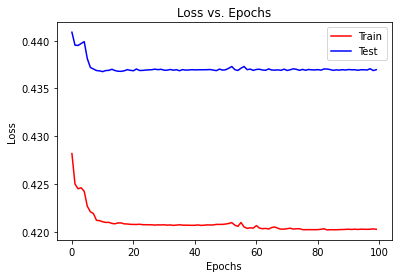

In [79]:
plt.plot(hist.history['loss'], color='red', label='Train')
plt.plot(hist.history['val_loss'], color='blue', label='Test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="upper right")
plt.title('Loss vs. Epochs')
plt.show()

In [30]:
model.summary()

Model: "AffineNet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
static (InputLayer)             [(None, 64, 128, 128 0                                            
__________________________________________________________________________________________________
moving (InputLayer)             [(None, 64, 128, 128 0                                            
__________________________________________________________________________________________________
concatenate_1 (Concatenate)     (None, 64, 128, 128, 0           static[0][0]                     
                                                                 moving[0][0]                     
__________________________________________________________________________________________________
conv3d_4 (Conv3D)               (None, 32, 64, 64, 1 880         concatenate_1[0][0]      

In [70]:
model.save_weights(checkpoint_path)

In [13]:
checkpoint_path = "./Affinecheck/1017_6cp.ckpt"
model.load_weights(checkpoint_path)

In [88]:
checkpoint_path = "./Affinecheck/1024_1cp.ckpt"
model.save_weights(checkpoint_path)

In [123]:
## 간단하게 결과 보기 위한 코드 ##
output = model.predict(sample_loader)
moved = output['moved_gt']
# deformation = output['deformation']
# moved_gt = output['moved_gt']x_copy = x_copy.swapaxes(0,2)

# moved = moved * max_value
print(moved.shape)
a = moved[1]
# b = deformation[0]
# c = moved_gt[0]

print(a.shape)
a = a.swapaxes(0,2) 
# b = b.swapaxes(0,2)
# c = c.swapaxes(0,2)
print(a.shape)

a = nib.Nifti1Image(a,None) 
# b = nib.Nifti1Image(b,None)
# c = nib.Nifti1Image(c,None)

nib.save(a,'BTCV_Data/sample.nii.gz')
# nib.save(b,'BTCV_Data/aff_deformation_0825_1.nii.gz')
# nib.save(c,'BTCV_Data/aff_gt_moved_0825_1.nii.gz')


(29, 64, 128, 128, 1)
(64, 128, 128, 1)
(128, 128, 64, 1)


In [80]:
f1model = Model(inputs=model.model.input, outputs=model.model.get_layer('x_theta').output)
real_theta = f1model.predict(sample_loader)

print(real_theta.shape)


(29, 6)


In [63]:
# Affine GT 만들기! 파일 불러와서 한번에 다 처리!##########
a = 1
j = 0
for i in range (0, 39):
    filename = "./BTCV_Data/0.name_img/" + str(a) + ".nii.gz"
    if os.path.isfile(filename):
        x = nib.load(filename).get_fdata()
        x = x.astype(np.float32)
        x = x.swapaxes(0,2)
        # print(x.shape)
        d,h,w = x.shape
        x = np.expand_dims(x,axis=0)
        x = np.expand_dims(x,axis=-1)

        theta_x, theta_y, theta_z = 0, 0, 0
        trans_x, trans_y, trans_z = 0, 0, 0 
        Rx, Ry, Rz = tf.ones([3,3]), tf.ones([3,3]), tf.ones([3,3])
               
        x_reshape = tf.reshape(real_theta[j], [6])
        theta_x, theta_y, theta_z, trans_x, trans_y, trans_z = x_reshape[0], x_reshape[1], x_reshape[2], x_reshape[3], x_reshape[4], x_reshape[5]
        
        R_x_sin, R_x_cos = tf.math.sin(theta_x),tf.math.cos(theta_x)
        R_y_sin, R_y_cos = tf.math.sin(theta_y), tf.math.cos(theta_z)
        R_z_sin, R_z_cos = tf.math.sin(theta_z), tf.math.cos(theta_y)
        
        Rx = [[1,0,0],[0,R_x_cos, -R_x_sin],[0, R_x_sin,R_x_cos]]
        Ry = [[R_y_cos,0, R_y_sin],[0,1,0], [-R_y_sin, 0, R_y_cos]]
        Rz = [[R_z_cos, -R_z_sin, 0], [R_z_sin, R_z_cos,0],[0,0,1]]
        
        R_matrix_1 = tf.matmul(Rx,Ry)
        R_matrix = tf.matmul(R_matrix_1, Rz)
        # 3 x 3 
        # R_matrix = tf.reshape(R_matrix, [1, 9])
        real_mat = [[R_matrix[0][0], R_matrix[0][1], R_matrix[0][2], trans_x],
                    [R_matrix[1][0], R_matrix[1][1], R_matrix[1][2], trans_y],
                    [R_matrix[2][0], R_matrix[2][1], R_matrix[2][2], trans_z]]
#         real_mat = tf.reshape(real_mat, [1, 9])
        
        nb = 1
        theta = tf.reshape(real_mat, [nb, 3, 4])
        grid = regular_grid_3d(d, h, w)
        grid_new = grid_transform_3d(real_mat, grid)
        grid_new = tf.clip_by_value(grid_new, -1, 1)
        
        moved = grid_sample_3d(x, grid_new, name='moved')
        
        x = np.squeeze(moved[0]) 
        # print(x.shape)
        
        d,h,w = x.shape
        x_copy = x.copy()
        
        x_copy = x_copy.swapaxes(0,2)
        print(a, ":", x_copy.shape )
        savename = "./BTCV_Data/1024_affine/" + str(a) + ".nii.gz"
        x_copy = nib.Nifti1Image(x_copy, None) 
        nib.save(x_copy,savename)
        
        j += 1
        
    a += 1


1 : (128, 128, 64)
2 : (128, 128, 64)
3 : (128, 128, 64)
4 : (128, 128, 64)
5 : (128, 128, 64)
6 : (128, 128, 64)
7 : (128, 128, 64)
8 : (128, 128, 64)
9 : (128, 128, 64)
10 : (128, 128, 64)
21 : (128, 128, 64)
22 : (128, 128, 64)
23 : (128, 128, 64)
24 : (128, 128, 64)
25 : (128, 128, 64)
26 : (128, 128, 64)
27 : (128, 128, 64)
28 : (128, 128, 64)
29 : (128, 128, 64)
30 : (128, 128, 64)
31 : (128, 128, 64)
32 : (128, 128, 64)
33 : (128, 128, 64)
34 : (128, 128, 64)
35 : (128, 128, 64)
36 : (128, 128, 64)
37 : (128, 128, 64)
38 : (128, 128, 64)
39 : (128, 128, 64)


In [81]:
# Affine GT 만들기! 파일 불러와서 한번에 다 처리!##########
a = 1
j = 0
for i in range (0, 39):
    filename = "./BTCV_Data/0.name_gt/" + str(a) + ".nii.gz"
    if os.path.isfile(filename):
        x = nib.load(filename).get_fdata()
        x = x.astype(np.float32)
        x = x.swapaxes(0,2)
        # print(x.shape)
        d,h,w = x.shape
        x = np.expand_dims(x,axis=0)
        x = np.expand_dims(x,axis=-1)

        theta_x, theta_y, theta_z = 0, 0, 0
        trans_x, trans_y, trans_z = 0, 0, 0 
        Rx, Ry, Rz = tf.ones([3,3]), tf.ones([3,3]), tf.ones([3,3])
               
        x_reshape = tf.reshape(real_theta[j], [6])
        theta_x, theta_y, theta_z, trans_x, trans_y, trans_z = x_reshape[0], x_reshape[1], x_reshape[2], x_reshape[3], x_reshape[4], x_reshape[5]
        
        R_x_sin, R_x_cos = tf.math.sin(theta_x),tf.math.cos(theta_x)
        R_y_sin, R_y_cos = tf.math.sin(theta_y), tf.math.cos(theta_z)
        R_z_sin, R_z_cos = tf.math.sin(theta_z), tf.math.cos(theta_y)
        
        Rx = [[1,0,0],[0,R_x_cos, -R_x_sin],[0, R_x_sin,R_x_cos]]
        Ry = [[R_y_cos,0, R_y_sin],[0,1,0], [-R_y_sin, 0, R_y_cos]]
        Rz = [[R_z_cos, -R_z_sin, 0], [R_z_sin, R_z_cos,0],[0,0,1]]
        
        R_matrix_1 = tf.matmul(Rx,Ry)
        R_matrix = tf.matmul(R_matrix_1, Rz)
        # 3 x 3 
        # R_matrix = tf.reshape(R_matrix, [1, 9])
        real_mat = [[R_matrix[0][0], R_matrix[0][1], R_matrix[0][2], trans_x],
                    [R_matrix[1][0], R_matrix[1][1], R_matrix[1][2], trans_y],
                    [R_matrix[2][0], R_matrix[2][1], R_matrix[2][2], trans_z]]
#         real_mat = tf.reshape(real_mat, [1, 9])
        
        nb = 1
        theta = tf.reshape(real_mat, [nb, 3, 4])
        grid = regular_grid_3d(d, h, w)
        grid_new = grid_transform_3d(real_mat, grid)
        grid_new = tf.clip_by_value(grid_new, -1, 1)
        
        moved = grid_sample_3d(x, grid_new, name='moved')
        
        x = np.squeeze(moved[0]) 
        # print(x.shape)
        
        d,h,w = x.shape
        x_copy = x.copy()
        
        x_copy = x_copy.swapaxes(0,2)
        print(a, ":", x_copy.shape )
        savename = "./BTCV_Data/1024_affine_gt/" + str(a) + ".nii.gz"
        x_copy = nib.Nifti1Image(x_copy, None) 
        nib.save(x_copy,savename)
        
        j += 1
        
    a += 1


1 : (128, 128, 64)
2 : (128, 128, 64)
3 : (128, 128, 64)
4 : (128, 128, 64)
5 : (128, 128, 64)
6 : (128, 128, 64)
7 : (128, 128, 64)
8 : (128, 128, 64)
9 : (128, 128, 64)
10 : (128, 128, 64)
21 : (128, 128, 64)
22 : (128, 128, 64)
23 : (128, 128, 64)
24 : (128, 128, 64)
25 : (128, 128, 64)
26 : (128, 128, 64)
27 : (128, 128, 64)
28 : (128, 128, 64)
29 : (128, 128, 64)
30 : (128, 128, 64)
31 : (128, 128, 64)
32 : (128, 128, 64)
33 : (128, 128, 64)
34 : (128, 128, 64)
35 : (128, 128, 64)
36 : (128, 128, 64)
37 : (128, 128, 64)
38 : (128, 128, 64)
39 : (128, 128, 64)


In [86]:
#### GT Stack 쌓아서 저장 ####

st = []
a=1
for i in range (0, 40):
    filename = "./BTCV_Data/1024_affine_gt/" + str(a) + ".nii.gz"
    if os.path.isfile(filename):
        x = nib.load(filename).get_fdata()
        x = x.swapaxes(0,2)
        st.append(x)
        
        
    a+=1  
st = np.array(st)
print(st.shape)

savename = "./BTCV_Data/1024_affine_1_exis_stack_gt.nii.gz"
x = nib.Nifti1Image(st, None) 
nib.save(x, savename)

(29, 64, 128, 128)


In [87]:
#### voxel Stack 쌓아서 저장 ####

st = []
a=1
for i in range (0, 40):
    filename = "./BTCV_Data/1024_affine/" + str(a) + ".nii.gz"
    if os.path.isfile(filename):
        x = nib.load(filename).get_fdata()
        x = x.swapaxes(0,2)
        st.append(x)
        
        
    a+=1  
st = np.array(st)
print(st.shape)

savename = "./BTCV_Data/1024_affine_1_exis_stack.nii.gz"
x = nib.Nifti1Image(st, None) 
nib.save(x, savename)

(29, 64, 128, 128)


In [31]:
model.summary()

Model: "AffineNet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
static (InputLayer)             [(None, 64, 128, 128 0                                            
__________________________________________________________________________________________________
moving (InputLayer)             [(None, 64, 128, 128 0                                            
__________________________________________________________________________________________________
concatenate_2 (Concatenate)     (None, 64, 128, 128, 0           static[0][0]                     
                                                                 moving[0][0]                     
__________________________________________________________________________________________________
conv3d_8 (Conv3D)               (None, 32, 64, 64, 1 880         concatenate_2[0][0]      

In [25]:
model.model.save('./affine_pb')

Instructions for updating:
This property should not be used in TensorFlow 2.0, as updates are applied automatically.
Instructions for updating:
This property should not be used in TensorFlow 2.0, as updates are applied automatically.
INFO:tensorflow:Assets written to: ./affine_pb/assets


In [30]:
tf.io.write_graph (model, 
                   './',
                   'affine_model',
                   as_text=True)

AttributeError: 'AffineNet' object has no attribute 'DESCRIPTOR'

In [16]:
import tensorflow as tf
from tensorflow.python.tools import freeze_graph

In [18]:
# checkpoint to pb file
freeze_graph.freeze_graph('/graph.pbtxt', "", False, 
                        "./Affinecheck/0925_1cp.h5", 'moved',
                        "save/restore_all", "save/Const",
                        'frozen.pb', True, "")


OSError: Input graph file '/graph.pbtxt' does not exist!

In [59]:
filename1 = "./BTCV_Data/aff_moved_0922_2.nii.gz"
filename2 = "./BTCV_Data/gt_resize/40.nii.gz"
x1 = nib.load(filename1).get_fdata()
x1 = x1.astype(np.float32)
x1 = np.squeeze(x1)

x2 = nib.load(filename2).get_fdata()
x2 = x2.astype(np.float32)    

def dice_coef_multilabel(y_true, y_pred, labels=13):
    w, h, d = y_true.shape
    label_interaction = []
    label_union = []
    total_dice = 0
    # print(y_true.shape)
    for m in range(0, labels+1):
        interact = 0
        gakgak = 0 
        for i in range(0, w):
            for j in range(0, h):
                for k in range(0, d):
                        if y_true[i][j][k] == m and y_pred[i][j][k] == m:
                            interact += 1
                        if y_true[i][j][k] == m:
                            gakgak += 1
                        if y_pred[i][j][k] == m:
                            gakgak += 1
        if interact != None:
            label_interaction.append(interact)
        else:
            label_interaction.append(0)
        if gakgak != None:
            label_union.append(gakgak)
        else:
            label_union.append(0)
        
        #print(label_interaction)
        
        dice = (label_interaction[m]*2) / label_union[m]
        total_dice += dice
        print("class: "+ str(m) + "    Dice: "+ str(dice))
        
    print("total_dice: " + str(total_dice / (labels+1)))

        
dice_coef_multilabel(x1, x2)

class: 0    Dice: 0.9251246519322365
class: 1    Dice: 0.0
class: 2    Dice: 0.12842234499693064
class: 3    Dice: 0.0
class: 4    Dice: 0.0
class: 5    Dice: 0.0
class: 6    Dice: 0.2182549371633752
class: 7    Dice: 0.06524905330614623
class: 8    Dice: 0.006186842647968653
class: 9    Dice: 0.1451831750339213
class: 10    Dice: 0.0
class: 11    Dice: 0.020056569812291078
class: 12    Dice: 0.0
class: 13    Dice: 0.0


ZeroDivisionError: division by zero

In [4]:
# 모듈 

import nibabel as nib
import os 
import numpy as np

# 
from os.path import join as pjoin
import numpy as np
from dipy.viz import regtools
from dipy.data import fetch_stanford_hardi
from dipy.data.fetcher import fetch_syn_data
from dipy.io.image import load_nifti
from dipy.align.imaffine import (transform_centers_of_mass,
                                 AffineMap,
                                 MutualInformationMetric,
                                 AffineRegistration)
from dipy.align.transforms import (TranslationTransform3D,
                                   RigidTransform3D,
                                   AffineTransform3D)

(128, 128, 64)
(128, 128, 64)
(128, 128, 64)


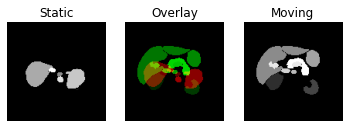

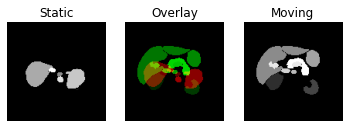

In [5]:
tf_op_layer_RealDiv_5_loss# files, folder = fetch_stanford_hardi()
static_data, static_affine, static_img = load_nifti(
                                            pjoin("./BTCV_Data/0.name_gt/40.nii.gz"),
                                            return_img=True)
static = static_data
static_grid2world = static_affine

moving_data, moving_affine, moving_img = load_nifti(
                                            pjoin("./BTCV_Data/0.name_gt/1.nii.gz"),
                                            return_img=True)
moving = moving_data
moving_grid2world = moving_affine

print(static_data.shape)
print(static.shape)
print(moving.shape)

identity = np.eye(4)
affine_map = AffineMap(identity,
                       static.shape, static_grid2world,
                       moving.shape, moving_grid2world)
resampled = affine_map.transform(moving)
# regtools.overlay_slices(static, resampled, None, 0,
#                         "Static", "Moving", "resampled_0.png")
# regtools.overlay_slices(static, resampled, None, 1,
#                         "Static", "Moving", "resampled_1.png")
regtools.overlay_slices(static, resampled, None, 2,
                        "Static", "Moving", "resampled_2.png")

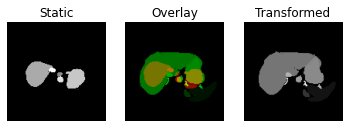

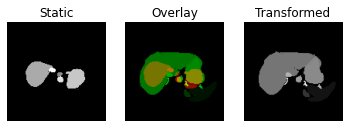

In [6]:
c_of_mass = transform_centers_of_mass(static, static_grid2world,
                                      moving, moving_grid2world)
transformed = c_of_mass.transform(moving)
# regtools.overlay_slices(static, transformed, None, 0,
#                         "Static", "Transformed", "transformed_com_0.png")
# regtools.overlay_slices(static, transformed, None, 1,one_hot
#                         "Static", "Transformed", "transformed_com_1.png")
regtools.overlay_slices(static, transformed, None, 2,
                        "Static", "Transformed", "transformed_com_2.png")



Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]


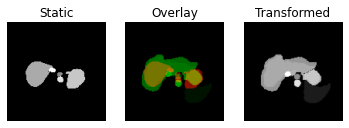

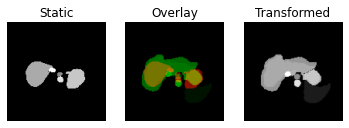

In [7]:
nbins = 32
sampling_prop = None
metric = MutualInformationMetric(nbins, sampling_prop)

level_iters = [10000, 1000, 100]

sigmas = [3.0, 1.0, 0.0]

factors = [4, 2, 1]

affreg = AffineRegistration(metric=metric,
                            level_iters=level_iters,
                            sigmas=sigmas,
                            factors=factors)

transform = TranslationTransform3D()
params0 = None
starting_affine = c_of_mass.affine
translation = affreg.optimize(static, moving, transform, params0,
                              static_grid2world, moving_grid2world,
                              starting_affine=starting_affine)

transformed = translation.transform(moving)
regtools.overlay_slices(static, transformed, None, 2,
                        "Static", "Transformed", "transformed_trans_2.png")

Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]


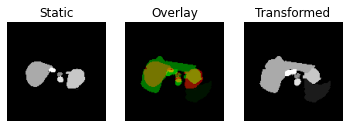

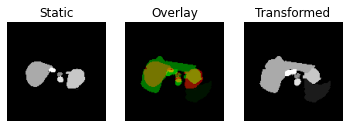

In [8]:
transform = RigidTransform3D()
params0 = None
starting_affine = translation.affine
rigid, xopt, fopt = affreg.optimize(static, moving, transform, params0,
                        static_grid2world, moving_grid2world,
                        starting_affine=starting_affine, ret_metric=True)

transformed = rigid.transform(moving, interpolation='nearest')
regtools.overlay_slices(static, transformed, None, 2,
                        "Static", "Transformed", "transformed_rigid_2.png")

In [9]:
filename2 = "./BTCV_Data/Rigid_gt/1.nii.gz"
x = transformed
x = nib.Nifti1Image(x, None) 
nib.save(x, filename2)


In [36]:
xopt

array([ 0.11228243,  0.12494267, -0.11601219,  0.92274326,  
       0.04815018, -0.07424364], dtype=float32)

array([-3.72256997e-04, -1.86304293e-03, -6.25327550e-03, -2.49071840e-04,
        2.24261128e-05, -2.41000258e-04])

In [37]:
filename1 = "./BTCV_Data/0.name_gt/1.nii.gz"

x1 = nib.load(filename1).get_fdata()
x1 = x1.astype(np.float32)
x1 = x1.swapaxes(0,2)
d = 64
h = 128
w = 128

x1 = np.expand_dims(x1,axis=0)
x1 = np.expand_dims(x1,axis=-1)

x1 = tf.cast(x1, 'float32')




(128, 128, 64)


In [40]:
theta = xopt
sa = tf.math.sin(theta[0])
ca = tf.math.cos(theta[0])
sb = tf.math.sin(theta[1])
cb = tf.math.cos(theta[1])
sc = tf.math.sin(theta[2])
cc = tf.math.cos(theta[2])
dx = theta[3]
dy = theta[4]
dz = theta[5]

R = tf.ones([3,3])

R[0,0], R[0,1], R[0,2] = cc*cb-sc*sa*sb, -sc*ca, cc*sb+sc*sa*cb
R[1,0], R[1,1], R[1,2] = sc*cb+cc*sa*sb, cc*ca, sc*sb-cc*sa*cb
R[2,0], R[2,1], R[2,2] = -ca*sb, sa, ca*cb
R[3,0], R[3,1], R[3,2] = 0, 0, 0
R[0,3] = dx
R[1,3] = dy
R[2,3] = dz
R[3,3] = 1



TypeError: 'tensorflow.python.framework.ops.EagerTensor' object does not support item assignment

In [45]:
R = tf.ones([3,3])
cc*cb-sc*sa*sb


<tf.Tensor: shape=(), dtype=float64, numpy=0.9999787172432204>

In [48]:
R_matrix[0][0]

<tf.Tensor: shape=(), dtype=float64, numpy=0.9999787129064124>

In [46]:
theta_x, theta_y, theta_z = 0, 0, 0
trans_x, trans_y, trans_z = 0, 0, 0 
Rx, Ry, Rz = tf.ones([3,3]), tf.ones([3,3]), tf.ones([3,3])

theta_x, theta_y, theta_z, trans_x, trans_y, trans_z = xopt[0], xopt[1], xopt[2], xopt[3], xopt[4], xopt[5]

R_x_sin, R_x_cos = tf.math.sin(theta_x), tf.math.cos(theta_x)
R_y_sin, R_y_cos = tf.math.sin(theta_y), tf.math.cos(theta_z)
R_z_sin, R_z_cos = tf.math.sin(theta_z), tf.math.cos(theta_y)

Rx = [[1,0,0],[0,R_x_cos, -R_x_sin],[0, R_x_sin,R_x_cos]]
Ry = [[R_y_cos,0, R_y_sin],[0,1,0], [-R_y_sin, 0, R_y_cos]]
Rz = [[R_z_cos, -R_z_sin, 0], [R_z_sin, R_z_cos,0],[0,0,1]]

R_matrix_1 = tf.matmul(Rx,Ry)
R_matrix = tf.matmul(R_matrix_1, Rz)
# 3 x 3 
# R_matrix = tf.reshape(R_matrix, [1, 9])
real_mat = [[R_matrix[0][0], R_matrix[0][1], R_matrix[0][2], trans_x],
            [R_matrix[1][0], R_matrix[1][1], R_matrix[1][2], trans_y],
            [R_matrix[2][0], R_matrix[2][1], R_matrix[2][2], trans_z]]

In [ ]:
nb = 1
theta = tf.reshape(real_mat, [nb, 3, 4])
grid = regular_grid_3d(d, h, w)
grid_new = grid_transform_3d(real_mat, grid)
grid_new = tf.clip_by_value(grid_new, -1, 1)

moved = grid_sample_3d(x1, grid_new, name='moved')

x1 = np.squeeze(moved[0]) 
# print(x.shape)

d,h,w = x1.shape
x_copy = x1.copy()

x_copy = x_copy.swapaxes(0,2)
print(x_copy.shape)

savename = "./BTCV_Data/1011Rigid_dipy.nii.gz"
x_copy = nib.Nifti1Image(x_copy, None) 
nib.save(x_copy,savename)

In [82]:
## DICE 산술평균 직접 구현 ## 
def dice_mean_multilabel(y_true, y_pred, labels=13):
    
    w, h, d  = y_true.shape
    label_interaction = []
    label_union = []
    total_dice = 0
    # print(y_true.shape)
    print("----Start Mean Dice----")
    for m in range(0, labels+1):
        interact = 0
        gakgak = 0 
        for i in range(0, w):
            for j in range(0, h):
                for k in range(0, d):
                        if y_true[i][j][k] == m and y_pred[i][j][k] == m:
                            interact += 1
                        if y_true[i][j][k] == m:
                            gakgak += 1
                        if y_pred[i][j][k] == m:
                            gakgak += 1
        if interact != None:
            label_interaction.append(interact)
        else:
            label_interaction.append(0)
        if gakgak != None:
            label_union.append(gakgak)
        else:
            label_union.append(0)
        
        #print(label_interaction)
        
        dice = (label_interaction[m]*2) / label_union[m]
        
        if m == 0:
            print("background Dice: "+ str(dice))
        else:
            total_dice += dice
            print("Label: "+ str(m) + "    Dice: "+ str(dice))
        
    print("total_dice: " + str(total_dice / (labels)))

In [83]:
# DICE Voxel Union #
def dice_voxel_union_multilabel(y_true, y_pred, labels=13):
    label_interaction = []
    label_union = []
    total_dice = 0
    smooth = 0.0001
    filename4 = "./BTCV_Data/14onehot_gt.nii.gz" 
    static_gt = nib.load(filename4).get_fdata()
    static_gt = static_gt.astype(np.float32)
    
    # print(y_true.shape)
    print("----Start Dice Voxel----")

    y_true_f = K.flatten(K.one_hot(K.cast(y_true, 'int32'), num_classes=14)[..., 1:])
    y_pred_f = K.flatten(static_gt[...,1:])
    intersect = K.sum(y_true_f * y_pred_f, axis=-1)
    denom = K.sum(y_true_f + y_pred_f, axis=-1)

    dice = K.mean((2. * intersect / (denom + smooth)))

    print("Total Dice: "+ str(dice))
    print("Total intersection: "+str(intersect))
    print("Total Union: "+str(denom))

In [84]:
# DICE Voxel Union #
def dice_all_union_multilabel(y_true, y_pred, labels=13):
    w, h, d   = y_true.shape
    label_interaction = []
    label_union = []
    total_dice = 0
    smooth = 0.0001
    print("----Start Dice All----")
    new_true = np.zeros((w,h,d))
    new_pred = np.zeros((w,h,d))

#     print(new_true.shape)
    for i in range(0, w):
        for j in range(0, h):
            for k in range(0, d):
                if y_true[i][j][k] != 0:
                    new_true[i][j][k] = 1
                if y_pred[i][j][k] != 0:
                    new_pred[i][j][k] = 1
    
    y_true_f = K.flatten(new_true[...])
    y_pred_f = K.flatten(new_pred[...])
    intersect = K.sum(y_true_f * y_pred_f, axis=-1)
    denom = K.sum(y_true_f + y_pred_f, axis=-1)

    dice = K.mean((2. * intersect / (denom + smooth)))
    print("Total Dice: "+ str(dice))
    print("Total intersection: "+str(intersect))
    print("Total Union: "+str(denom))

In [85]:
filename1 = "./BTCV_Data/1024_affine_gt/1.nii.gz"
filename2 = "./BTCV_Data/0.name_gt/40.nii.gz"

x1 = nib.load(filename1).get_fdata()
x1 = x1.astype(np.float32)
x2 = nib.load(filename2).get_fdata()

x2 = x2.astype(np.float32)    
# print(x1.shape)
# print(x2.shape)


dice_mean_multilabel(x1, x2)
dice_voxel_union_multilabel(x1, x2)
dice_all_union_multilabel(x1,x2)

----Start Mean Dice----
background Dice: 0.9326928174831304
Label: 1    Dice: 0.0
Label: 2    Dice: 0.10078110116212612
Label: 3    Dice: 0.0031120331950207467
Label: 4    Dice: 0.0
Label: 5    Dice: 0.0
Label: 6    Dice: 0.2200083490347839
Label: 7    Dice: 0.08073001234006624
Label: 8    Dice: 0.0
Label: 9    Dice: 0.09575217085191269
Label: 10    Dice: 0.0
Label: 11    Dice: 0.02904636920384952
Label: 12    Dice: 0.0
Label: 13    Dice: 0.0
total_dice: 0.040725387368289165
----Start Dice Voxel----
Total Dice: tf.Tensor(0.13646804, shape=(), dtype=float32)
Total intersection: tf.Tensor(11824.0, shape=(), dtype=float32)
Total Union: tf.Tensor(173286.0, shape=(), dtype=float32)
----Start Dice All----
Total Dice: tf.Tensor(0.25273824760642044, shape=(), dtype=float64)
Total intersection: tf.Tensor(21898.0, shape=(), dtype=float64)
Total Union: tf.Tensor(173286.0, shape=(), dtype=float64)
